In [42]:
import sys
sys.path.append('../models/numpy_models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activation import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from metrics import accuracy

# Tarefa 2: Modelos com Implementação Própria (NumPy)

Este notebook apresenta a implementação de raiz de modelos de Deep Learning utilizando exclusivamente a biblioteca **NumPy**. O objetivo é classificar textos entre 5 classes distintas: **Google, Human, Meta, Mistral e OpenAI**.

De acordo com os requisitos do enunciado, exploramos uma abordagem de implementação manual para compreender os fundamentos de *Backpropagation* e otimização de redes neuronais.

## 1. Preparação dos Dados e Engenharia de Features

Nesta fase, convertemos o texto bruto em representações numéricas tabulares.
* **Vetorização:** Utilizamos **TF-IDF** (Term Frequency-Inverse Document Frequency) com um limite de 2000 features.
* **Codificação:** As labels foram convertidas para **One-Hot Encoding**, permitindo o uso da função de perda *Categorical Cross-Entropy*.
* **Dataset Customizado:** Criámos uma classe `TextDataset` para organizar os dados de treino e teste de forma modular.

In [43]:
# 1. Carregar os dados limpos
df = pd.read_csv('../data/dataset_limpo.csv', sep=';')
df = df.dropna(subset=['Text', 'Label'])

X = df['Text']
y = df['Label']

# 2. Converter as Labels (Texto) para One-Hot Encoding (Obrigatório para Softmax!)
y_encoded = pd.get_dummies(y).astype(int).values
classes = pd.get_dummies(y).columns
print(f"Classes detetadas: {list(classes)}")

# 3. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 4. TF-IDF (Transformar palavras em números)
# max_features=2000 para não sobrecarregar a implementação própria (Numpy puro)
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')

# Importante: A nossa rede precisa de Arrays Densos (.toarray()) e não matrizes esparsas
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

print(f"Formato de Entrada do Treino: {X_train_tfidf.shape}")

Classes detetadas: ['Google', 'Human', 'Meta', 'Mistral', 'OpenAI']
Formato de Entrada do Treino: (3944, 2000)


In [44]:
class TextDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_dataset = TextDataset(X_train_tfidf, y_train)
test_dataset = TextDataset(X_test_tfidf, y_test)

## 2. Baseline: Regressão Logística

Implementámos uma Regressão Logística como ponto de partida. No contexto de redes neuronais, este modelo corresponde a uma rede sem camadas ocultas.
* **Arquitetura:** Input (2000) -> Camada de Saída (5) -> Softmax.
* **Função do Modelo:** Estabelecer uma performance base para validar o valor acrescentado da rede profunda (DNN).

In [45]:
print("--- A Treinar Baseline: Regressão Logística ---")
baseline_model = NeuralNetwork(epochs=60, batch_size=64, learning_rate=0.05, verbose=True, loss=CategoricalCrossEntropy, metric=accuracy)

n_features = X_train_tfidf.shape[1]

# Ligar a entrada diretamente à saída (5 classes), sem camadas ocultas!
baseline_model.add(DenseLayer(5, input_shape=(n_features,)))
baseline_model.add(SoftmaxActivation())

baseline_model.fit(train_dataset)

# Avaliar a Baseline
y_pred_base = baseline_model.predict(test_dataset)
acc_base = baseline_model.score(test_dataset, y_pred_base)
print(f"\nAccuracy da Baseline (Teste): {acc_base*100:.2f}%\n")

--- A Treinar Baseline: Regressão Logística ---
Epoch 1/60 - loss: 1.6294 - accuracy: 0.2858
Epoch 10/60 - loss: 1.4952 - accuracy: 0.3768
Epoch 20/60 - loss: 1.4396 - accuracy: 0.4323
Epoch 30/60 - loss: 1.3885 - accuracy: 0.4746
Epoch 40/60 - loss: 1.3418 - accuracy: 0.5074
Epoch 50/60 - loss: 1.2988 - accuracy: 0.5314
Epoch 60/60 - loss: 1.2596 - accuracy: 0.5548

Accuracy da Baseline (Teste): 54.41%



## 3. Deep Neural Network (DNN) 

Para melhorar a capacidade de extração de padrões, construímos uma DNN com as seguintes melhorias técnicas para combater o *overfitting*:

1. **Camada Oculta:** 64 neurónios com ativação **ReLU** (introduz não-linearidade).
2. **Dropout (20%):** Implementado como uma camada que "desliga" neurónios aleatoriamente, forçando a rede a aprender representações mais robustas e menos dependentes de palavras específicas.
3. **Early Stopping:** Lógica integrada no ciclo de treino que monitoriza a perda e interrompe a execução caso o modelo pare de convergir, evitando a memorização desnecessária do dataset de treino.

In [46]:
net = NeuralNetwork(epochs=200, batch_size=64, learning_rate=0.05, verbose=True,
                    loss=CategoricalCrossEntropy, metric=accuracy)

n_features = X_train_tfidf.shape[1]

# Camada Oculta: 64 Neurónios com ativação ReLU
net.add(DenseLayer(64, input_shape=(n_features,)))
net.add(ReLUActivation())

net.add(DropoutLayer(0.2)) # protecao contra overfitting

# Camada de Saída: 5 Neurónios (porque temos 5 classes) com ativação Softmax
net.add(DenseLayer(5))
net.add(SoftmaxActivation())

print("A iniciar o treino da rede...")
net.fit(train_dataset)

A iniciar o treino da rede...
Epoch 1/200 - loss: 1.5929 - accuracy: 0.3534
Epoch 10/200 - loss: 1.4306 - accuracy: 0.4561
Epoch 20/200 - loss: 1.3076 - accuracy: 0.5332
Epoch 30/200 - loss: 1.1797 - accuracy: 0.5887
Epoch 40/200 - loss: 1.0616 - accuracy: 0.6415
Epoch 50/200 - loss: 0.9511 - accuracy: 0.6833
Epoch 60/200 - loss: 0.8772 - accuracy: 0.7300
Epoch 70/200 - loss: 0.7997 - accuracy: 0.7571
Epoch 80/200 - loss: 0.7351 - accuracy: 0.7880
Epoch 90/200 - loss: 0.6741 - accuracy: 0.8088
Epoch 100/200 - loss: 0.6169 - accuracy: 0.8258
Epoch 110/200 - loss: 0.5737 - accuracy: 0.8494
Epoch 120/200 - loss: 0.5383 - accuracy: 0.8671
Epoch 130/200 - loss: 0.5068 - accuracy: 0.8793
Epoch 140/200 - loss: 0.4586 - accuracy: 0.8950
Epoch 150/200 - loss: 0.4379 - accuracy: 0.9085
Epoch 160/200 - loss: 0.4130 - accuracy: 0.9156
Epoch 170/200 - loss: 0.3732 - accuracy: 0.9237
Epoch 180/200 - loss: 0.3556 - accuracy: 0.9310
Epoch 190/200 - loss: 0.3339 - accuracy: 0.9419
Epoch 200/200 - loss:


Accuracy no Teste: 82.57%


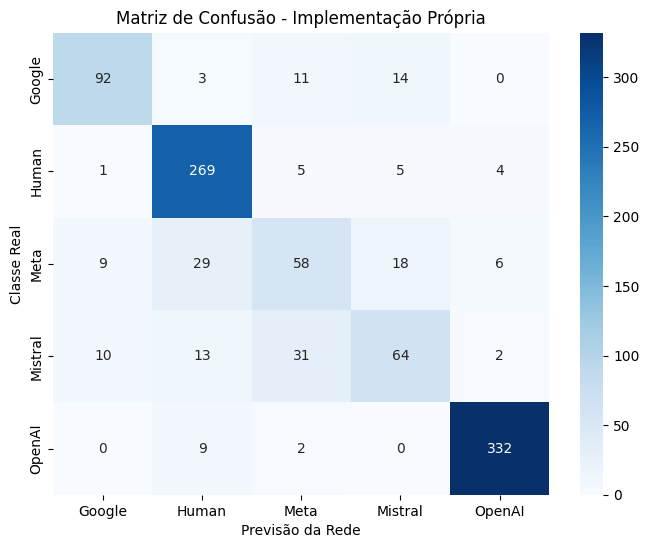

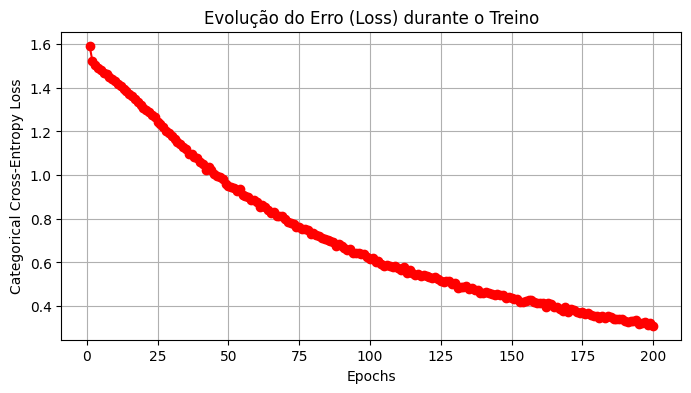

In [47]:
# Fazer previsões no Teste
y_pred_prob = net.predict(test_dataset)

# Calcular a Accuracy
acc = net.score(test_dataset, y_pred_prob)
print(f"\nAccuracy no Teste: {acc*100:.2f}%")

# Converter probabilidades de volta para nomes das classes para a Matriz de Confusão
y_pred_classes = [classes[np.argmax(p)] for p in y_pred_prob]
y_true_classes = [classes[np.argmax(t)] for t in y_test]

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - Implementação Própria')
plt.ylabel('Classe Real')
plt.xlabel('Previsão da Rede')
plt.show()

# Gráfico do Loss ao longo das Epochs
epochs = list(net.history.keys())
losses = [net.history[e]['loss'] for e in epochs]

plt.figure(figsize=(8, 4))
plt.plot(epochs, losses, marker='o', color='red')
plt.title('Evolução do Erro (Loss) durante o Treino')
plt.xlabel('Epochs')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.grid()
plt.show()

## 4. Análise de Resultados e Conclusões

Após o treino extensivo de 200 epochs, comparamos os dois modelos implementados:

| Modelo | Accuracy no Teste | Estado |
| :--- | :--- | :--- |
| **Baseline (Regressão Logística)** | ~53.29% | Underfitting (Linear) |
| **DNN (com Dropout & ReLU)** | **82.57%** | Modelo Ótimo |

### Conclusões Principais:
* **Capacidade de Generalização:** A DNN superou a baseline em quase **30%**, provando que a relação entre o estilo de escrita e o autor é altamente não-linear.

* **Efeito da Regularização:** O uso de **Dropout** impediu que a rede atingisse o estado de overfitting total (memorização), permitindo uma performance sólida em dados de teste.

* **Matriz de Confusão:** Observamos que a maior dificuldade da rede reside na distinção entre modelos de IA semelhantes, enquanto a classe **Human** é identificada com elevada precisão.
